This is market regime indicators

SQN: system quality number measure the system drift compared to the std over given period. It does not have any prediction power by definition. It only measure the past behavior. But if we assume market regime does not switch dramatically, then this can be used as an indicator. But we have to bear in mind it has a delay there. It is better to combine with other market regime which focus on regime change to avoid the market regime delay. 

The trend line of the market regime reflect long term trend with daily high frequency. we can explore how valid this is. 

* setup 
    * rule: long term moving SQN change is positive
    * short term: in consolidation
* Trigger:
    * break out

In [1]:
from sts.dio.equity import TickerDatabase as Ticker
import plotly.io as pio
import pandas as pd
import numpy as np
from sts.stsig.ta.market_regime import SQNRegime
from sts.quant.candle import Candle
import os

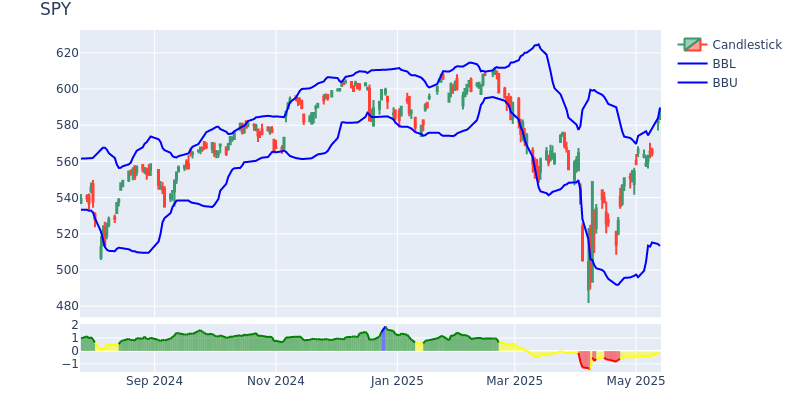

YFRateLimitError: Too Many Requests. Rate limited. Try after a while.

In [2]:
# ticker = Ticker('^NDX', data_mode = Ticker.DATAMODE.LOCAL, local_data_folder = '../../../data/market_data/' )
pio.renderers.default = os.environ.get("PLOTLY_RENDERER", "png")
sqn_regime_dict = {}
resample_rule = "1D"
rule_period_map = {"1D": "2y", "1W": "5y", "1M": "10y"}
period = rule_period_map[resample_rule]
future = ["^SPX", "^NDX", "^RUT", "GC=F", "HG=F", "SI=F", "CL=F", "TLT", "KWEB"]
single_name = [
    "MRVL",
    "ADBE",
    "ANET",
    "PWR",
    "AMD",
    "GOOGL",
    "NVDA",
    "META",
    "ASML",
    "TSLA",
    "PFE",
    "IWM",
    "AVGO",
    "FTNT",
    "MMM",
    "TRV",
    "LMT",
]
etf = [
    "SPY",
    "QQQ",
    "IWM",
    "GLD",
    "SLV",
    "CPER",
    "USO",
    "TLT",
    "KWEB",
    "PPA",
    "IBIT",
    "XLF",
    "XLI",
    "XLB",
    "XLC",
    "XLY",
    "XLP",
    "XLV",
    "XBI",
    "XLK",
    "XLU",
    "XME",
]
fx = ["JPY=X", "GBPUSD=X", "AUDUSD=X", "EURUSD=X", "CADUSD=X"]
for sym in etf + single_name + fx:
    ticker = Ticker(sym)
    df = Candle(ticker.history(period=period))
    if resample_rule != "1D":  # 1D resample is calendar day
        df = df.resample(resample_rule)
    sqn_window = 40 if sym in single_name else 100
    sqn_regime = SQNRegime(sqn_window=sqn_window)
    sqn_regime.set_data(df)
    fig = sqn_regime.plot(sqn_regime.df.iloc[-200:])
    fig.update_layout(title=sym, height=400, width=800, margin={"t": 30, "b": 20})
    fig.show()
    sqn_regime_dict[sym] = sqn_regime